In [1]:
import sys
import os

# This adds the parent directory to the search path
sys.path.append(os.path.abspath(".."))


%load_ext autoreload
%autoreload 2
from src.mltoolbox import *

# import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt 


How to build the confusion matrix?

We want to classify cat vs dog, for cat class:

- True positive (TP): it is the total counts having both predicted and actual values are cat
- True negative (TN): it is the total counts having both predicted and actual values are dog (not cat)
- False positive (FP): it is the total counts having predicted cat and actual values are dog (not cat)
- False negative (FN): it is the total counts having predicted dog and actual values are cat

The confusion matrix is 2x2:
```
TP | FN 
-------
FP | TN
```
(columns = preds, rows = actual)

Actual (first 30):
[1 0 0 0 2 2 1 1 1 2 2 0 2 0 1 0 2 1 0 0 0 0 1 1 1 0 2 2 1 1]

Predictions (first 30):
[1 0 0 0 2 2 0 1 1 2 2 0 2 0 1 1 2 0 2 0 0 0 2 1 1 0 2 2 1 1]


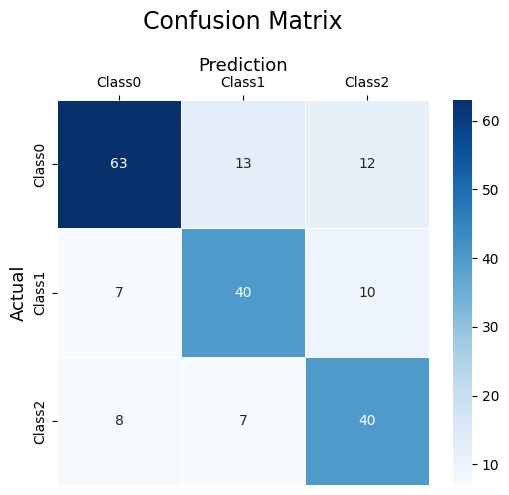

              precision    recall  f1-score   support

      Class0       0.81      0.72      0.76        88
      Class1       0.67      0.70      0.68        57
      Class2       0.65      0.73      0.68        55

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.72      0.71      0.72       200



In [20]:
### Generate data: actuals and predictions labels from experiment
rng = np.random.default_rng(0)

num_class = 3
num_samples = 200

# class distribution for y_true (must sum to 1, length = num_class)
probs_true = np.array([0.5, 0.3, 0.2])
y_true = rng.choice(num_class, size=num_samples, p=probs_true)
# print(f"Actual: \n{y_true}")

# "skill": probability of predicting correctly
p_correct = 0.75
y_pred = np.empty(num_samples, dtype=int)

for i, t in enumerate(y_true):
    if rng.random() < p_correct:
        y_pred[i] = t                          # correct => predict the true class
    else:
        # wrong => choose one of the other classes (uniformly)
        wrong_classes = [c for c in range(num_class) if c != t]
        y_pred[i] = rng.choice(wrong_classes)

print(f"Actual (first 30):\n{y_true[:30]}")
print(f"\nPredictions (first 30):\n{y_pred[:30]}")

### --- confusion matrix ---
labels = list(range(num_class))
cm = confusion_matrix(y_true, y_pred, labels=labels)
# print(cm)

# --- Plot ---
class_names = ["Class0", "Class1", "Class2"]  # rename e.g. ["Dog","Cat","Rabbit"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="g",
    cmap="Blues",              # <- blue palette
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white"
)
plt.ylabel("Actual", fontsize=13)
plt.title("Confusion Matrix", fontsize=17, pad=20)
plt.gca().xaxis.set_label_position("top")
plt.xlabel("Prediction", fontsize=13)
plt.gca().xaxis.tick_top()
plt.show()

# --- Report ---
print(classification_report(y_true, y_pred, target_names=class_names))

# Metrics understanding

## Example: confusion matrix 3x3

In [22]:
# --- define 3x3 confusion matrix ---

cm = np.array([
    [40,  2,  3],
    [ 4, 30,  6],
    [ 1,  5, 35]
])

num_class = cm.shape[0]
num_samples = cm.sum()

print("Confusion matrix:\n", cm)
print("\nTotal samples:", num_samples)

Confusion matrix:
 [[40  2  3]
 [ 4 30  6]
 [ 1  5 35]]

Total samples: 126


The structure: for class $k$, we treat as one-vs-rest

- `TP_k = cm[k,k]`
- `FN_k = sum(row k) - TP_k`
- `FP_k = sum(col k) - TP_k`
- `TN_k = everything else`

In [ ]:
# --- compute TP, FP, FN, TN for each class
metrics = {}

for k in range(num_class):
    TP = cm[k,k]                # correctly predicted
    FN = cm[k,:].sum() - TP     # actual class predicted as something else
    FP = cm[:,k].sum() - TP     # predicted class but actually not class
    TN = num_samples - (TP+FN+FP) # everything else

    metrics[k] = {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN
    }

print(metrics)

{0: {'TP': np.int64(40), 'FP': np.int64(5), 'FN': np.int64(5), 'TN': np.int64(76)}, 1: {'TP': np.int64(30), 'FP': np.int64(7), 'FN': np.int64(10), 'TN': np.int64(79)}, 2: {'TP': np.int64(35), 'FP': np.int64(9), 'FN': np.int64(6), 'TN': np.int64(76)}}


1. Precision (for class k): $\frac{TP}{TP+FP}$; of all points predicted as class k, how many were correct?
2. Recall (for class k): $\frac{TP}{TP+FN}$; of all true class k points, how many did we capture?
3. F1 score: harmonic mean $2\frac{PR}{P+R}$; penalizes imbalance between precision (P) and recall (R)
4. Oveall accuracy: sum of diagonal / total

In [26]:
# --- compute precision, recall, F1 ---
for k in range(num_class):
    TP = metrics[k]["TP"]
    FP = metrics[k]["FP"]
    FN = metrics[k]["FN"]

    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = 2 * precision * recall / (precision + recall)

    metrics[k]["precision"] = precision
    metrics[k]["recall"] = recall
    metrics[k]["f1"] = f1

for k in range(num_class):
    print(f"\nClass {k}")
    for key, value in metrics[k].items():
        print(f"{key}: {value}")

accuracy = np.trace(cm) / num_samples
print("\nAccuracy:", accuracy)


Class 0
TP: 40
FP: 5
FN: 5
TN: 76
precision: 0.8888888888888888
recall: 0.8888888888888888
f1: 0.8888888888888888

Class 1
TP: 30
FP: 7
FN: 10
TN: 79
precision: 0.8108108108108109
recall: 0.75
f1: 0.7792207792207791

Class 2
TP: 35
FP: 9
FN: 6
TN: 76
precision: 0.7954545454545454
recall: 0.8536585365853658
f1: 0.8235294117647058

Accuracy: 0.8333333333333334


Intuition:

1. High precision for spam filter: emails flagged as spam are almost always spam
2. Low precision for spam filter: you lose important emails
3. High recall for cancer detection: you catch most sick patients
4. Low recall for cancer detection: many sick patients go undetected